# Neural Network Unlearning with SISA
## Bias Reduction : Four Strategies Compared
**Dataset:** Iowa recidivism combined with injected COMPAS rows  
**Model:** Neural Network trained with SISA (15 shards × 10 slices)

**Point Removal strategies:**
- S1: COMPAS Injection Removal  
- S2: Per-Shard ForSId  
- S3: Maximum FP Removal (stress test)  

**Non-removal strategy:**
- S4: Inline Per-Slice Fairness Calibration (Not making any data removal) 


## 1. Imports

In [65]:
import os, sys, time, importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
from scipy.spatial.distance import jensenshannon


## 2. Configuration

In [66]:
CSV_PATH      = 'combined_adapted_with_counts.csv'
SISA_MODULE   = 'SISA.py' #Contains SISA structure
OUT           = 'results/' #Figure Storing
PROCESSED_DIR = 'processed_data/' 
CHECKPOINT_DIR = 'checkpoints/' #Directory to save checkpoints 

SEED       = 42
TEST_SIZE  = 0.20
VAL_SIZE   = 0.15

THRESHOLD   = 0.57  #Classification threshold
BLACK_LABEL = 'Black'
WHITE_LABEL = 'White'

# ForSId config
FORSID_LAMBDA     = 1.0
FORSID_SIMILARITY = 'cosine'

NUM_SHARDS = 15 #SISA number of shards (Can affect fpr of baselines and after retrainning)
NUM_SLICES = 10 #SISA number of slices

eps = 1e-10 #To avoid zero when computing Jensen-Shanon Divergence

os.makedirs(OUT, exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)
torch.manual_seed(SEED)
np.random.seed(SEED)
print(f'Configuration loaded | Threshold: {THRESHOLD} | Shards: {NUM_SHARDS} | Slices: {NUM_SLICES}')


Configuration loaded | Threshold: 0.57 | Shards: 15 | Slices: 10


## 3. Load & Encode Data

In [67]:
df = pd.read_csv(CSV_PATH)
df.columns = [c.strip() for c in df.columns]

if "source" in df.columns:
    is_injected_all = (df["source"].str.strip().str.lower() == "compas").to_numpy(dtype=bool) #Will be used to remove by flag
    df = df.drop(columns=["source"])
else:
    print("WARNING: 'source' column not found — is_injected will be all False")
    is_injected_all = np.zeros(len(df), dtype=bool)

TARGET = "recidivism"
CAT_COLS = ["age_cat", "offense_classification", "offense_type", "race"]
NUM_COLS = ["priors_count", "juv_fel_count", "juv_misd_count", "juv_other_count"]

race_col = df["race"].astype(str).to_numpy() #Useful for tracking bias
y = df[TARGET].to_numpy(dtype=np.float32)

#Concatenating numerical and categorical features
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype="float32")
X_cat = ohe.fit_transform(df[CAT_COLS].astype(str))
scaler = StandardScaler()
X_num = scaler.fit_transform(df[NUM_COLS]).astype("float32")
X = np.concatenate([X_cat, X_num], axis=1).astype("float32")
FEATURES = ohe.get_feature_names_out(CAT_COLS).tolist() + NUM_COLS

print(f"Data loaded | Rows: {len(df)} | Recidivism rate: {y.mean():.2f} | Features: {len(FEATURES)}")
print(f"  Race dist: { {r: int((race_col==r).sum()) for r in sorted(set(race_col))} }")


Data loaded | Rows: 33199 | Recidivism rate: 0.36 | Features: 20
  Race dist: {'Asian': 224, 'Black': 9807, 'Hispanic': 2221, 'Native American': 520, 'Other': 377, 'White': 20050}


## 4. Train / Val / Test Split

In [68]:
idx_all = np.arange(len(X))

(X_trainval, X_test,
 y_trainval, y_test,
 race_trainval, race_test,
 injected_trainval, injected_test,
 idx_trainval, idx_test) = train_test_split(
    X, y, race_col, is_injected_all, idx_all,
    test_size=TEST_SIZE, random_state=SEED, stratify=y)

(X_train, X_val,
 y_train, y_val,
 race_train, race_val,
 injected_train, injected_val,
 idx_train, idx_val) = train_test_split(
    X_trainval, y_trainval, race_trainval, injected_trainval, idx_trainval,
    test_size=VAL_SIZE, random_state=SEED, stratify=y_trainval)
    
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
pos_w = float(n_neg / n_pos)

print(f"Trainval: {X_trainval.shape} | Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")


Trainval: (26559, 20) | Train: (22575, 20) | Val: (3984, 20) | Test: (6640, 20)


## 5. Fairness & Evaluation Helpers

In [69]:
def compute_bias(y_true, y_pred, race_labels):
    ''' Compute FPR, FNR, and accuracy for each race group '''
    out = {}
    for race in sorted(set(race_labels)):
        mask = race_labels == race
        if mask.sum() < 3: continue
        yt, yp = y_true[mask].astype(int), y_pred[mask].astype(int)
        tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0,1]).ravel()
        out[race] = dict(n=int(mask.sum()),
                         accuracy=float(accuracy_score(yt, yp)),
                         FPR=fp/(fp+tn) if (fp+tn)>0 else 0.0,
                         FNR=fn/(fn+tp) if (fn+tp)>0 else 0.0)
    return out


def collapse_bias(bias_dict):
    ''' Pool all races except Black and White into a single Other category '''
    out    = {k: bias_dict[k] for k in ('Black','White') if k in bias_dict}
    others = {r: m for r, m in bias_dict.items() if r not in ('Black','White')}
    if others:
        n = sum(m['n'] for m in others.values())
        out['Other'] = dict(n=n,
            accuracy=sum(m['accuracy']*m['n'] for m in others.values())/n,
            FPR=sum(m['FPR']*m['n']      for m in others.values())/n,
            FNR=sum(m['FNR']*m['n']      for m in others.values())/n)
    return out


print('Bias helpers defined')


Bias helpers defined


## 7. Save Dataset Bundle & Load SISA Module (with no unlearning)

In [70]:
def load_sisa_module():
    spec = importlib.util.spec_from_file_location('sisa', SISA_MODULE)
    module = importlib.util.module_from_spec(spec)
    sys.modules['sisa'] = module
    spec.loader.exec_module(module)
    return module

def sisa_predict_proba(models, X_np):
    sisa = load_sisa_module()
    x_t = torch.tensor(X_np, dtype=torch.float32)
    probs = sisa.aggregate_probabilities(models, x_t)
    return probs.detach().cpu().numpy()[:, 1]

def sisa_predict_binary(models, X_np, shard_thresholds=None):
    sisa = load_sisa_module()
    x_t = torch.tensor(X_np, dtype=torch.float32)
    probs = sisa.aggregate_probabilities(models, x_t)
    prob_np = probs.detach().cpu().numpy()[:, 1]
    if shard_thresholds:
        votes = np.zeros(len(X_np))
        for shard_id, model in enumerate(models):
            model.eval()
            with torch.no_grad():
                p = torch.softmax(model(x_t), dim=1)[:, 1].numpy()
            t = shard_thresholds.get(shard_id, THRESHOLD)
            votes += (p >= t).astype(float)
        pred = (votes >= len(models) / 2).astype(int)
    else:
        pred =(prob_np >= THRESHOLD).astype(int)
    return pred,prob_np

print('Helpers defined')


Helpers defined


In [71]:
# Save bundle with race_train so the SISA.py file can access it during training
np.savez(
    PROCESSED_DIR + 'dataset_bundle.npz',
    X_train=X_train.astype(np.float32),
    y_train=y_train.astype(np.int64),
    X_test=X_test.astype(np.float32),
    y_test=y_test.astype(np.int64),
    feature_names=np.array(FEATURES, dtype=object),
    race_train=race_train,
)

if 'sisa' in sys.modules:
    del sys.modules['sisa']
sisa = load_sisa_module()

# Plain SISA baseline:fairness_target=1.0 never triggers calibration
t_sisa_start = time.time()
dataset, x_train_t, y_train_t, x_test_t, y_test_t, _ = sisa.load_dataset()

sisa_models, sisa_shards, sisa_all_slices, _ = sisa.train_sisa(
    dataset, NUM_SHARDS, NUM_SLICES,
    pos_weight = pos_w,
    fairness_target = 1.0,
    global_threshold = THRESHOLD,
)
t_sisa_full = time.time() - t_sisa_start

sisa_before_pred, sisa_before_prob = sisa_predict_binary(sisa_models, X_test)
baseline_bias = compute_bias(y_test.astype(int), sisa_before_pred, race_test)

base_fpr_b = baseline_bias.get(BLACK_LABEL, {}).get('FPR', float('nan'))
base_fpr_w = baseline_bias.get(WHITE_LABEL, {}).get('FPR', float('nan'))
base_gap   = base_fpr_b - base_fpr_w

sisa_base_acc = sisa.evaluate(sisa_models, x_test_t, y_test_t, threshold=THRESHOLD)

print(f'SISA baseline complete')
print(f'Training time  : {t_sisa_full:.1f}s')
print(f'Shards         : {NUM_SHARDS} × {NUM_SLICES} slices')
print(f'SISA accuracy  : {sisa_base_acc:.2f}')
print(f'Black FPR      : {base_fpr_b:.2f}')
print(f'White FPR      : {base_fpr_w:.2f}')
print(f'Bias gap       : {base_gap:+.2f}')


SISA baseline complete
Training time  : 20.7s
Shards         : 15 × 10 slices
SISA accuracy  : 0.63
Black FPR      : 0.22
White FPR      : 0.16
Bias gap       : +0.06


## 7. SISA Unlearning Helper


In [72]:
def run_sisa_unlearning(global_indices_to_forget, use_fairness=False):
    '''
    Standard SISA unlearning.
    use_fairness=True to inline per-slice calibration (used by S4).
    '''
    selected_removal = list(global_indices_to_forget)
    t0 = time.time()  # start timing before location search
    locations = sisa.find_example_locations(selected_removal, sisa_shards, sisa_all_slices)
    updated_models = list(sisa_models)
    updated_thresholds = {}
    for shard_id, info in locations.items():
        updated_models[shard_id] = sisa.unlearn_examples(
            shard_id, sisa_all_slices[shard_id], info['example_indices'],
            pos_weight = pos_w,
            fairness_target = 1.0,
            global_threshold = THRESHOLD,
            shard_thresholds = updated_thresholds,
        )
    t_unlearn = time.time() - t0
    return updated_models, updated_thresholds, t_unlearn

print('Unlearning helper defined')


Unlearning helper defined


## 10. Strategy 1 : COMPAS Injection Removal  *(Point Removal)*
Forget set: all rows injected from COMPAS (known bias source).

In [73]:
s1_local_idx = np.where(injected_train)[0]
s1_global_idx = idx_train[s1_local_idx]
print(f'Forget set size: {len(s1_local_idx)} injected COMPAS rows')

sisa_s1_models, _, t_unlearn_s1 = run_sisa_unlearning(s1_global_idx)
sisa_s1_pred, sisa_s1_prob = sisa_predict_binary(sisa_s1_models, X_test)
s1_bias = compute_bias(y_test.astype(int), sisa_s1_pred, race_test)

fpr_s1 = s1_bias.get(BLACK_LABEL, {}).get('FPR', float('nan'))
s1_gap = fpr_s1 - s1_bias.get(WHITE_LABEL, {}).get('FPR', float('nan'))
js_s1 = jensenshannon(sisa_before_prob + eps, sisa_s1_prob + eps) #How does the model diverge from baseline

print(f'\nStrategy 1 : Black FPR: {fpr_s1:.2f}  gap to white: {s1_gap:+.2f}')
print(f'Accuracy : {accuracy_score(y_test.astype(int), sisa_s1_pred):.2f}')
print(f'AUC      : {roc_auc_score(y_test.astype(int), sisa_s1_prob):.2f}')
print(f'Unlearn time: {t_unlearn_s1:.2f}s  '
      f'({t_unlearn_s1 / t_sisa_full * 100:.1f}% of full train)')
print(f'JS divergence: {js_s1:.6f}')


Forget set size: 4893 injected COMPAS rows

Strategy 1 : Black FPR: 0.25  gap to white: +0.12
Accuracy : 0.64
AUC      : 0.60
Unlearn time: 17.57s  (84.8% of full train)
JS divergence: 0.025927


## 11. Strategy 2 : Per-Shard ForSId  *(Point Removal)*
Each shard's **own model** scores its **own training points**.

In [74]:

# NNModel.net = [Linear(in,128), ReLU, Dropout, Linear(128,64), ReLU, Dropout, Linear(64,2)]
# indices:               0         1     2         3               4     5         6
# We take index 5 (Dropout after second hidden layer) → 64-dim penultimate representation.

class ShardFeatureExtractor(nn.Module):
    """Extracts penultimate 64-dim activations from the SISA NNModel."""
    def __init__(self, model):
        super().__init__()
        self.model = model
        self._features = None
        self._hook = model.net[5].register_forward_hook(self._save)

    def _save(self, m, inp, out): self._features = out

    def forward(self, x):
        with torch.no_grad(): self.model(x)
        return self._features

    def remove_hook(self): self._hook.remove()


def shard_get_hidden_features(shard_model, X_np):
    ext = ShardFeatureExtractor(shard_model)
    shard_model.eval()
    with torch.no_grad():
        h = ext(torch.tensor(X_np, dtype=torch.float32))
    ext.remove_hook()
    return h.numpy()


def shard_compute_residuals(shard_model, X_np, y_np):
    """residual(t) = softmax_prob_class1(t) - y_t"""
    shard_model.eval()
    with torch.no_grad():
        logits= shard_model(torch.tensor(X_np, dtype=torch.float32))
        probs_c1 = torch.softmax(logits, dim=1)[:, 1]
        y_t = torch.tensor(y_np, dtype=torch.float32)
        residuals = (probs_c1 - y_t).numpy()
    return residuals.astype(np.float32)


def compute_similarity_matrix(h_train, h_ref, similarity="cosine"):
    if similarity == "cosine":
        h_train_n = h_train / (np.linalg.norm(h_train, axis=1, keepdims=True) + 1e-10)
        h_ref_n = h_ref / (np.linalg.norm(h_ref,   axis=1, keepdims=True) + 1e-10)
        return h_train_n @ h_ref_n.T
    return h_train @ h_ref.T


def compute_forsid_scores_for_shard(shard_model, X_cand, y_cand,
                                     X_unwanted, X_wanted,
                                     lambda_weight=1.0, similarity="cosine"):
    """
    score(t) = impact_unwanted(t) - lambda * impact_wanted(t)
    """
    shard_model.eval()
    h_cand = shard_get_hidden_features(shard_model, X_cand)
    h_unwanted = shard_get_hidden_features(shard_model, X_unwanted)
    h_wanted = shard_get_hidden_features(shard_model, X_wanted)
    residuals = shard_compute_residuals(shard_model, X_cand, y_cand)
    S_u = compute_similarity_matrix(h_cand, h_unwanted, similarity)
    S_w = compute_similarity_matrix(h_cand, h_wanted,   similarity)
    impact_unwanted = (residuals[:, np.newaxis] * S_u).mean(axis=1)
    impact_wanted = (residuals[:, np.newaxis] * S_w).mean(axis=1)
    scores = impact_unwanted - lambda_weight * impact_wanted
    ranked_idx = np.argsort(scores)[::-1]
    return scores, ranked_idx


print("Per-shard ForSId helpers defined")


Per-shard ForSId helpers defined


In [75]:
# Build probe sets (shared across all shards)
# Du: Black non-recidivists from TEST set : the people harmed by high Black FPR
probe_mask = (race_test == BLACK_LABEL) & (y_test.astype(int) == 0)
X_probe = X_test[probe_mask]
print(f"Probe set (Du): {len(X_probe)} Black non-recidivists in test set")

# Dw: correctly predicted validation examples (All correct preds)
sisa_val_pred, _ = sisa_predict_binary(sisa_models, X_val)
dw_mask = (sisa_val_pred == y_val.astype(int))
X_wanted = X_val[dw_mask]
print(f"Wanted set (Dw): {dw_mask.sum()} correctly predicted val examples")

# Score each shard with its own model
print("\nScoring each shard with its own model...")

all_scores = []   # (shard_id, local_pos, score, global_idx)

for shard_id, (shard_model, shard) in enumerate(zip(sisa_models, sisa_shards)):
    shard_indices = shard.indices
    X_shard = x_train_t[shard_indices].numpy()
    y_shard = y_train_t[shard_indices].numpy().astype(np.float32)

    if len(X_shard) == 0:
        continue

    scores, _ = compute_forsid_scores_for_shard(
        shard_model = shard_model,
        X_cand = X_shard,
        y_cand = y_shard,
        X_unwanted = X_probe,
        X_wanted = X_wanted,
        lambda_weight = FORSID_LAMBDA,
        similarity = FORSID_SIMILARITY,
    )

    n_positive = int((scores > 0).sum())
    mean_pos_str = f"{scores[scores>0].mean():.2f}" if n_positive > 0 else "0.0000"
    print(f"Shard {shard_id:2d}: {n_positive:2d} positive-score points "
          f"(max={scores.max():.2f}, mean_pos={mean_pos_str})")

    for local_pos, score in enumerate(scores):
        global_idx = int(idx_train[shard_indices[local_pos]])
        all_scores.append((shard_id, local_pos, score, global_idx))

TOP_K_PER_SHARD = 34   # ~500 total across 15 shards, same scale as RF code

shard_groups = {}
for sid, lpos, sc, gidx in all_scores:
    if sc > 0:
        shard_groups.setdefault(sid, []).append((sid, lpos, sc, gidx))

positive_scores = []
for sid, group in shard_groups.items():
    group_sorted = sorted(group, key=lambda x: x[2], reverse=True)
    positive_scores.extend(group_sorted[:TOP_K_PER_SHARD])

s2_natural_k = len(positive_scores)
s2_global_idx = np.array([gidx for _, _, _, gidx in positive_scores])
s2_local_idx = np.array([np.where(idx_train == gidx)[0][0]
    for gidx in s2_global_idx
    if len(np.where(idx_train == gidx)[0]) > 0
])

shards_hit = len(set(sid for sid, _, _, _ in positive_scores))
print(f"\nForget set (top-{TOP_K_PER_SHARD} per shard)  : {s2_natural_k} points")
print(f"{s2_natural_k / len(X_train) * 100:.1f}% of training data")
print(f"Shards affected : {shards_hit} / {NUM_SHARDS}")
if len(s2_local_idx) > 0:
    print(f"of which COMPAS : {injected_train[s2_local_idx].sum()}")


Probe set (Du): 1172 Black non-recidivists in test set
Wanted set (Dw): 2495 correctly predicted val examples

Scoring each shard with its own model...
Shard  0: 642 positive-score points (max=0.17, mean_pos=0.04)
Shard  1: 701 positive-score points (max=0.11, mean_pos=0.03)
Shard  2: 605 positive-score points (max=0.13, mean_pos=0.05)
Shard  3: 816 positive-score points (max=0.08, mean_pos=0.02)
Shard  4: 705 positive-score points (max=0.06, mean_pos=0.01)
Shard  5: 616 positive-score points (max=0.09, mean_pos=0.02)
Shard  6: 718 positive-score points (max=0.09, mean_pos=0.02)
Shard  7: 610 positive-score points (max=0.13, mean_pos=0.03)
Shard  8: 687 positive-score points (max=0.13, mean_pos=0.03)
Shard  9: 700 positive-score points (max=0.11, mean_pos=0.02)
Shard 10: 625 positive-score points (max=0.09, mean_pos=0.02)
Shard 11: 773 positive-score points (max=0.08, mean_pos=0.02)
Shard 12: 653 positive-score points (max=0.07, mean_pos=0.02)
Shard 13: 661 positive-score points (max=0

In [76]:
sisa_s2_models, _, t_unlearn_s2 = run_sisa_unlearning(s2_global_idx)
sisa_s2_pred, sisa_s2_prob = sisa_predict_binary(sisa_s2_models, X_test)
s2_bias = compute_bias(y_test.astype(int), sisa_s2_pred, race_test)

fpr_s2 = s2_bias.get(BLACK_LABEL, {}).get('FPR', float('nan'))
s2_gap = fpr_s2 - s2_bias.get(WHITE_LABEL, {}).get('FPR', float('nan'))
js_s2 = jensenshannon(sisa_s2_prob + eps, sisa_before_prob + eps)

print(f'\nStrategy 2 : Black FPR: {fpr_s2:.2f}  gap to white: {s2_gap:+.2f}')
print(f'Accuracy : {accuracy_score(y_test.astype(int), sisa_s2_pred):.2f}')
print(f'AUC      : {roc_auc_score(y_test.astype(int), sisa_s2_prob):.2f}')
print(f'Unlearn time: {t_unlearn_s2:.2f}s  '
      f'({t_unlearn_s2 / t_sisa_full * 100:.1f}% of full train)')
print(f'JS divergence: {js_s2:.6f}')



Strategy 2 : Black FPR: 0.24  gap to white: +0.14
Accuracy : 0.64
AUC      : 0.60
Unlearn time: 20.05s  (96.8% of full train)
JS divergence: 0.019496


## 12. Strategy 3 : Maximum FP Removal  *(Point Removal)*
Forget set: all Black non-recidivists currently predicted positive by SISA.

In [77]:
sisa_train_probs = sisa_predict_binary(sisa_models, X_train)[1]
sisa_train_preds = (sisa_train_probs >= THRESHOLD).astype(int)

s3_mask = ((race_train == BLACK_LABEL) &
           (y_train.astype(int) == 0) &
           (sisa_train_preds == 1))
s3_local_idx = np.where(s3_mask)[0]
s3_global_idx = idx_train[s3_local_idx]

print(f'Black non-recidivists in train : 'f'{int(((race_train == BLACK_LABEL) & (y_train.astype(int) == 0)).sum())}')
print(f'Of which predicted positive    : {len(s3_local_idx)}')

sisa_s3_models, _, t_unlearn_s3 = run_sisa_unlearning(s3_global_idx)
sisa_s3_pred, sisa_s3_prob = sisa_predict_binary(sisa_s3_models, X_test)
s3_bias = compute_bias(y_test.astype(int), sisa_s3_pred, race_test)

fpr_s3 = s3_bias.get(BLACK_LABEL, {}).get('FPR', float('nan'))
s3_gap = fpr_s3 - s3_bias.get(WHITE_LABEL, {}).get('FPR', float('nan'))
js_s3 = jensenshannon(sisa_s3_prob + eps, sisa_before_prob + eps)
p3_acc = accuracy_score(y_test.astype(int), sisa_s3_pred)

print(f'\nStrategy 3 — Black FPR: {fpr_s3:.4f}  gap: {s3_gap:+.4f}')
print(f'Accuracy : {p3_acc:.4f}')
print(f'AUC      : {roc_auc_score(y_test.astype(int), sisa_s3_prob):.4f}')
print(f'Unlearn time: {t_unlearn_s3:.2f}s  '
      f'({t_unlearn_s3 / t_sisa_full * 100:.1f}% of full train)')
print(f'JS divergence: {js_s3:.6f}')
if p3_acc < 0.52:
    print('  *** COLLAPSE DETECTED ***')


Black non-recidivists in train : 4007
Of which predicted positive    : 815

Strategy 3 — Black FPR: 0.2159  gap: +0.1674
Accuracy : 0.6383
AUC      : 0.5970
Unlearn time: 20.09s  (97.0% of full train)
JS divergence: 0.021217


## 13. Strategy 4 : Inline Per-Slice Fairness Calibration
The Strategy: SISA retrains the affected shards with fairness 
calibration 

```
For each shard s, for each slice i:
    Load checkpoint shard{s}_slice{i}.pt
    Measure Black FPR on cumulative data e1 + e2 + ... + ei
    If FPR > target:
        Sweep thresholds → find lowest t where FPR ≤ target
        Store shard_thresholds[s] = t
```


In [ ]:
def run_s4_calibration(models, shards, all_slices, num_slices,
                        fairness_target, threshold):
    '''
    Inline per-slice threshold calibration using saved checkpoints.
    Loads each shard's slice checkpoints, measures Black FPR after each slice,
    and stores a fair threshold if the target is exceeded.
    '''
    updated_models = list(models)
    updated_thresholds = {}
    t0 = time.time()

    for shard_id, shard in enumerate(shards):
        slices = all_slices[shard_id]
        for slice_id in range(num_slices):
            # Load checkpoint for this shard at this slice
            ckpt_path = f"{sisa.CHECKPOINT_DIR}/shard{shard_id}_slice{slice_id}.pt"
            model = sisa.NNModel(input_size=x_train_t.shape[1], num_classes=2)
            model.load_state_dict(torch.load(ckpt_path, map_location="cpu"))
            model.eval()

            # Build cumulative dataset up to this slice (no removal)
            cumulative = sisa.combine_slices(slices[:slice_id + 1])

            # Measure Black FPR on this shard's cumulative training data
            fpr_b, n_black = sisa.compute_shard_black_fpr(
                model, cumulative, threshold=threshold)

            if n_black >= 5 and fpr_b > fairness_target:
                # SISA Find fair threshold
                fair_t = sisa.find_fair_threshold(
                    model, cumulative,
                    fpr_target       = fairness_target,
                    global_threshold = threshold)
                updated_thresholds[shard_id] = fair_t
            elif n_black >= 5 and fpr_b <= fairness_target:
                # Already fair
                updated_thresholds[shard_id] = threshold

        # Final model for this shard is the last slice checkpoint
        final_ckpt = f"{sisa.CHECKPOINT_DIR}/shard{shard_id}_slice{num_slices-1}.pt"
        final_model = sisa.NNModel(input_size=x_train_t.shape[1], num_classes=2)
        final_model.load_state_dict(torch.load(final_ckpt, map_location="cpu"))
        updated_models[shard_id] = final_model

        t_final = updated_thresholds.get(shard_id, threshold)
        print(f'Shard {shard_id:2d}: threshold = {t_final:.2f}  '
              f'{"raised" if t_final > threshold else "  default"}')

    return updated_models, updated_thresholds, time.time() - t0

In [ ]:

# Inline per-slice fairness calibration
FAIRNESS_TARGET = 0.05  # target Black FPR per slice (used by S4 to calibrate the threshold)
print(f'Forget set: {len(s1_global_idx)} injected COMPAS rows (same as S1)')
print(f'Fairness target: Black FPR ≤ {FAIRNESS_TARGET} per slice\n')

t_s4_start = time.time()
sisa_s4_models, sisa_s4_thresholds, t_calibrate_s4 = run_s4_calibration(  # inline calibration enabled with no points removal
    models          = sisa_models,
    shards          = sisa_shards,
    all_slices      = sisa_all_slices,
    num_slices      = NUM_SLICES,
    fairness_target = FAIRNESS_TARGET,
    threshold       = THRESHOLD,
)

t_unlearn_s4 = time.time() - t_s4_start

sisa_s4_pred, sisa_s4_prob = sisa_predict_binary(
    sisa_s4_models, X_test, shard_thresholds=sisa_s4_thresholds)
s4_bias = compute_bias(y_test.astype(int), sisa_s4_pred, race_test)

fpr_s4 = s4_bias.get(BLACK_LABEL, {}).get('FPR', float('nan'))
s4_gap = fpr_s4 - s4_bias.get(WHITE_LABEL, {}).get('FPR', float('nan'))
js_s4 = jensenshannon(sisa_s4_prob + eps, sisa_before_prob + eps)

print(f'\nStrategy 4 : Black FPR: {fpr_s4:.2f}  gap: {s4_gap:+.2f}')
print(f'Accuracy : {accuracy_score(y_test.astype(int), sisa_s4_pred):.2f}')
print(f'AUC      : {roc_auc_score(y_test.astype(int), sisa_s4_prob):.2f}')
print(f'Unlearn time: {t_unlearn_s4:.2f}s  '
      f'({t_unlearn_s4 / t_sisa_full * 100:.1f}% of full train)')
print(f'JS divergence: {js_s4:.6f}')
print(f'\n Shard thresholds calibrated during retraining:')
for sid in sorted(sisa_s4_thresholds):
    t = sisa_s4_thresholds[sid]
    marker = 'raised' if t > THRESHOLD else '  default'
    print(f'Shard {sid:2d}: {t:.2f}  {marker}')


Forget set: 4893 injected COMPAS rows (same as S1)
Fairness target: Black FPR ≤ 0.05 per slice

Shard  0: threshold = 0.64  ↑ raised
Shard  1: threshold = 0.65  ↑ raised
Shard  2: threshold = 0.76  ↑ raised
Shard  3: threshold = 0.57    default
Shard  4: threshold = 0.71  ↑ raised
Shard  5: threshold = 0.76  ↑ raised
Shard  6: threshold = 0.66  ↑ raised
Shard  7: threshold = 0.77  ↑ raised
Shard  8: threshold = 0.76  ↑ raised
Shard  9: threshold = 0.81  ↑ raised
Shard 10: threshold = 0.81  ↑ raised
Shard 11: threshold = 0.74  ↑ raised
Shard 12: threshold = 0.76  ↑ raised
Shard 13: threshold = 0.63  ↑ raised
Shard 14: threshold = 0.68  ↑ raised

Strategy 4 : Black FPR: 0.05  gap: +0.04
Accuracy : 0.65
AUC      : 0.60
Unlearn time: 1.81s  (8.8% of full train)
JS divergence: 0.021217

 Shard thresholds calibrated during retraining:
Shard  0: 0.64  ↑ raised
Shard  1: 0.65  ↑ raised
Shard  2: 0.76  ↑ raised
Shard  3: 0.57    default
Shard  4: 0.71  ↑ raised
Shard  5: 0.76  ↑ raised
Shard  6

## 8. Visualizations


In [80]:
C_BASE = "#E07B54"
C_S1   = "#4C72B0"
C_S2   = "#55A868"
C_S3   = "#C44E52"
C_S4   = "#BCBD22" 

STRATEGY_COLORS = {
    "Baseline":   C_BASE,
    "Strategy 1": C_S1,
    "Strategy 2": C_S2,
    "Strategy 3": C_S3,
    "Strategy 4": C_S4,
}

y_test_int = y_test.astype(int)

bias_variants = {
    "Baseline":   collapse_bias(baseline_bias),
    "Strategy 1": collapse_bias(s1_bias),
    "Strategy 2": collapse_bias(s2_bias),
    "Strategy 3": collapse_bias(s3_bias),
    "Strategy 4": collapse_bias(s4_bias),
}

metric_variants = {
    "Baseline":dict(accuracy=accuracy_score(y_test_int, sisa_before_pred), auc=roc_auc_score(y_test_int, sisa_before_prob)),
    "Strategy 1":  dict(accuracy=accuracy_score(y_test_int, sisa_s1_pred), auc=roc_auc_score(y_test_int, sisa_s1_prob)),
    "Strategy 2":  dict(accuracy=accuracy_score(y_test_int, sisa_s2_pred), auc=roc_auc_score(y_test_int, sisa_s2_prob)),
    "Strategy 3":  dict(accuracy=accuracy_score(y_test_int, sisa_s3_pred), auc=roc_auc_score(y_test_int, sisa_s3_prob)),
    "Strategy 4":  dict(accuracy=accuracy_score(y_test_int, sisa_s4_pred), auc=roc_auc_score(y_test_int, sisa_s4_prob)),
}

races_fig   = ["Black", "White", "Other"]
model_names = list(bias_variants.keys())
colors_list = [STRATEGY_COLORS[k] for k in model_names]
print("Visualization data prepared")


Visualization data prepared


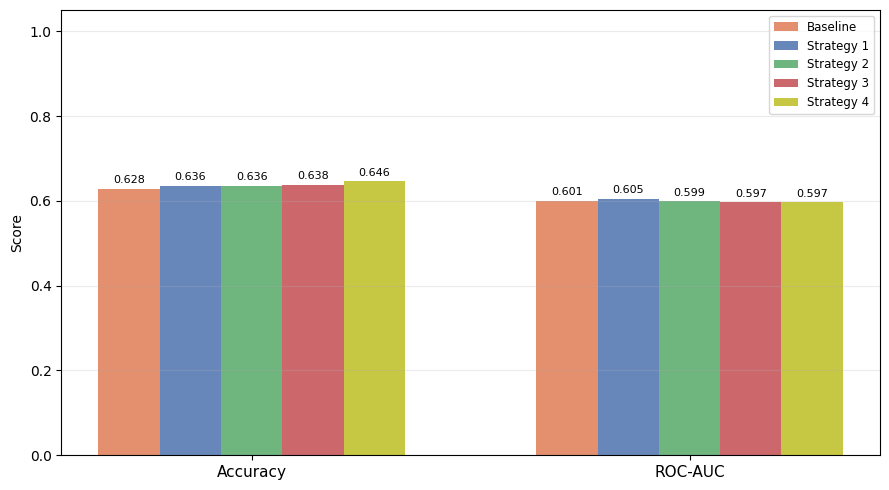

In [81]:
def save_fig(name):
    plt.tight_layout()
    plt.savefig(OUT + name, dpi=150, bbox_inches="tight")
    plt.show(); plt.close()

def label_bars(ax, bars, fmt="{:.2f}", offset=0.008):
    ''' Add value labels on top of each bar '''
    for bar in bars:
        v = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, v + offset, fmt.format(v), ha="center", va="bottom", fontsize=8)

strategies = ["Strategy 1", "Strategy 2", "Strategy 3", "Strategy 4"]
all_labels = ["Baseline"] + strategies
s_colors = [C_S1, C_S2, C_S3, C_S4]
all_colors = [C_BASE] + s_colors

# Figure 1: Accuracy & AUC
fig, ax = plt.subplots(figsize=(9, 5))
x, w = np.arange(2), 0.14
for i, mn in enumerate(model_names):
    vals = [metric_variants[mn]["accuracy"], metric_variants[mn]["auc"]]
    label_bars(ax, ax.bar(x + i*w, vals, w, label=mn, color=colors_list[i], alpha=0.85), "{:.3f}")
ax.set_xticks(x + w*2); ax.set_xticklabels(["Accuracy", "ROC-AUC"], fontsize=11)
ax.set_ylim(0, 1.05); ax.set_ylabel("Score"); ax.legend(fontsize=8.5)
ax.grid(axis="y", alpha=0.25)
save_fig("fig_sisa_nn_overall.png")





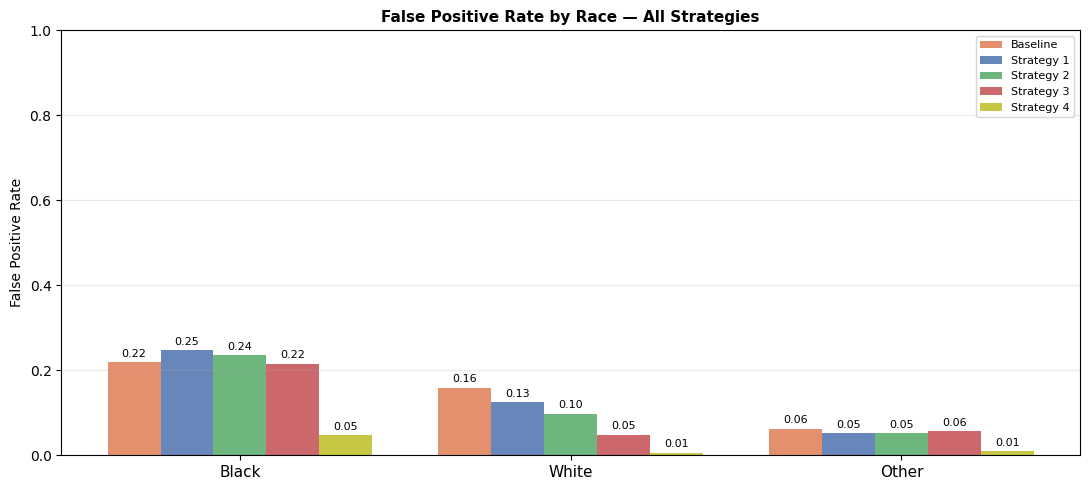

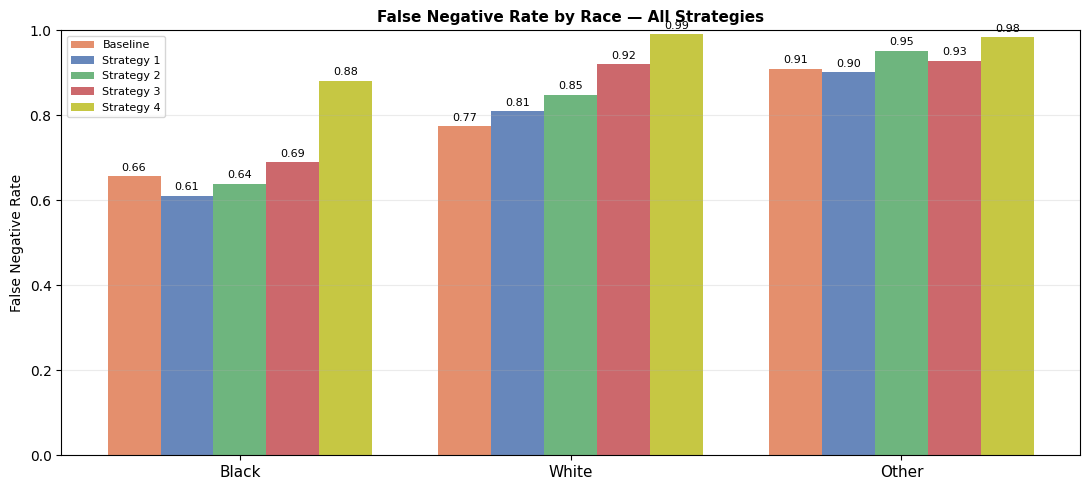

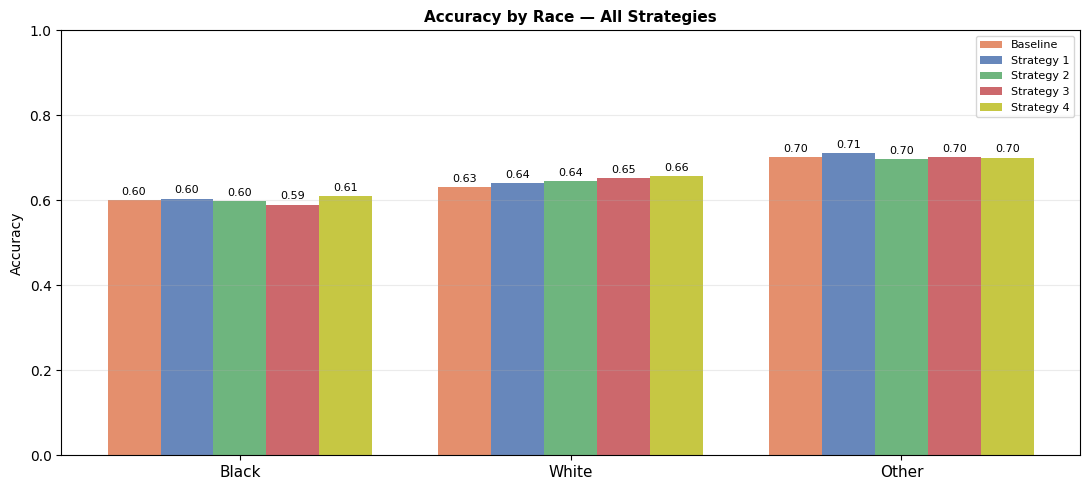

In [82]:
# Figures 2-4: FPR, FNR, Accuracy by Race
for key, ylabel, fname in [
    ("FPR", "False Positive Rate", "fig_sisa_nn_fpr_by_race.png"),
    ("FNR", "False Negative Rate", "fig_sisa_nn_fnr_by_race.png"),
    ("accuracy", "Accuracy", "fig_sisa_nn_accuracy_by_race.png"),
]:
    fig, ax = plt.subplots(figsize=(11, 5))
    x, w = np.arange(len(races_fig)), 0.16
    for i, mn in enumerate(model_names):
        vals = [bias_variants[mn].get(r, {}).get(key, 0) for r in races_fig]
        label_bars(ax, ax.bar(x + i*w, vals, w, label=mn, color=colors_list[i], alpha=0.85))
    ax.set_xticks(x + w*2); ax.set_xticklabels(races_fig, fontsize=11)
    ax.set_ylabel(ylabel); ax.set_ylim(0, 1.0)
    ax.set_title(f"{ylabel} by Race — All Strategies", fontsize=11, fontweight="bold")
    ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.25)
    save_fig(fname)

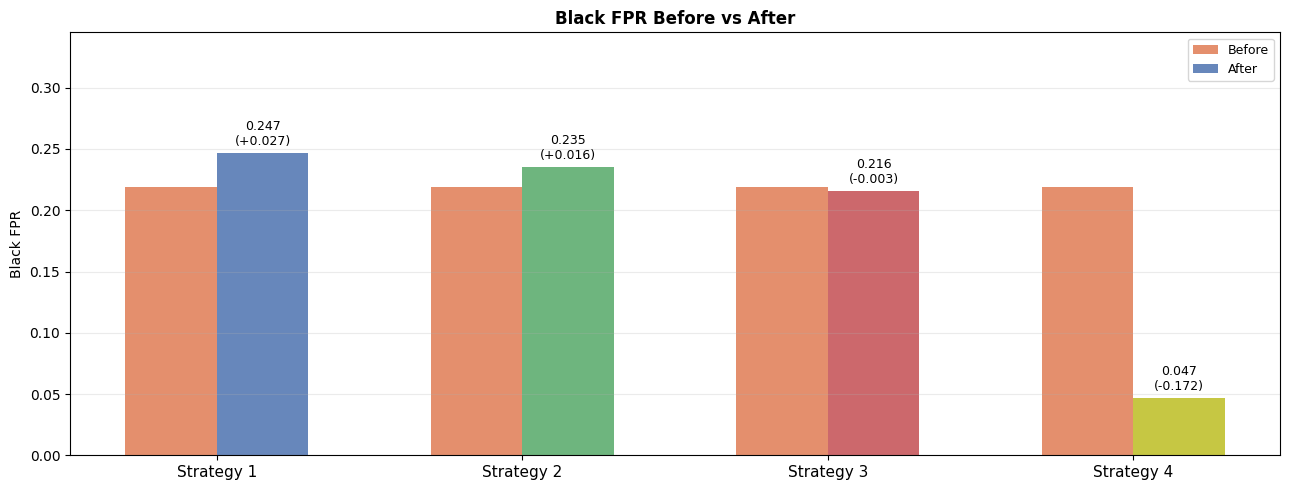

In [83]:
# Figure 5: Black FPR Before vs After 
fpr_before = [base_fpr_b] * 4
fpr_after = [bias_variants[s].get("Black", {}).get("FPR", 0) for s in strategies]
fig, ax = plt.subplots(figsize=(13, 5))
x, w = np.arange(4), 0.3
ax.bar(x - w/2, fpr_before, w, label="Before", color=C_BASE, alpha=0.85)
for bar, v in zip(ax.bar(x + w/2, fpr_after, w, label="After", color=s_colors, alpha=0.85), fpr_after):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
            f"{v:.3f}\n({v - base_fpr_b:+.3f})", ha="center", va="bottom", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(strategies, fontsize=11)
ax.set_ylabel("Black FPR"); ax.set_ylim(0, max(fpr_before + fpr_after) * 1.4)
ax.set_title("Black FPR Before vs After", fontsize=12, fontweight="bold")
ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.25)
save_fig("fig_sisa_nn_black_fpr_delta.png")


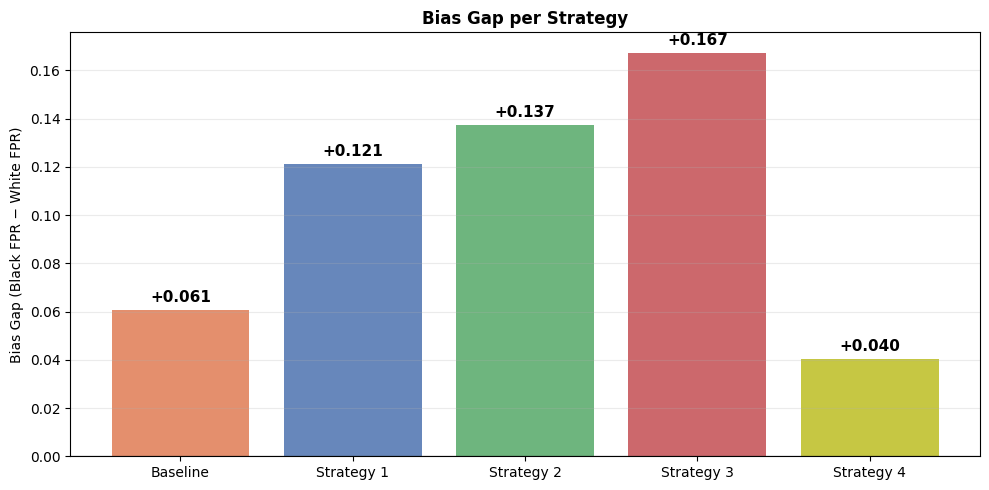

In [84]:
# Figure 6: Bias Gap
gaps = [bias_variants[l].get("Black", {}).get("FPR", 0) - bias_variants[l].get("White", {}).get("FPR", 0) for l in all_labels]
fig, ax = plt.subplots(figsize=(10, 5))
for bar, v in zip(ax.bar(all_labels, gaps, color=all_colors, alpha=0.85), gaps):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{v:+.3f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("Bias Gap (Black FPR − White FPR)")
ax.set_title("Bias Gap per Strategy", fontsize=12, fontweight="bold")
ax.grid(axis="y", alpha=0.25)
save_fig("fig_sisa_nn_bias_gap.png")

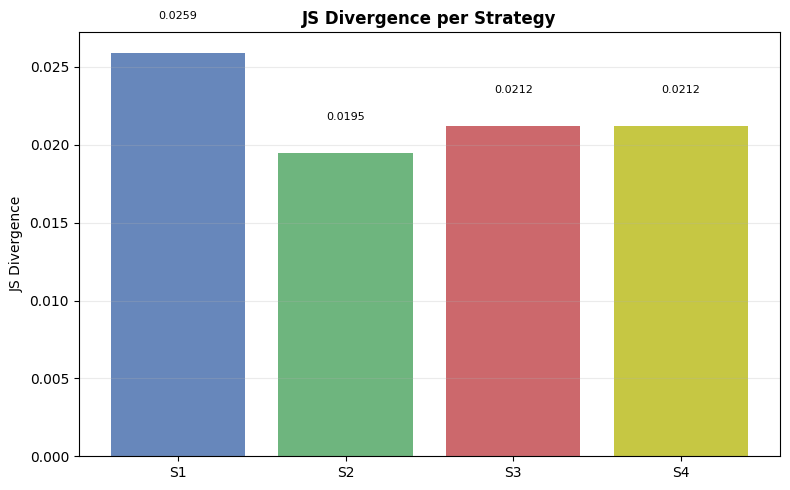

In [85]:
# Figure 7: JS Divergence
#Measuring how much the prediction probabilities change compared to the baseline after unlearning
js_vals = [js_s1, js_s2, js_s3, js_s4]
fig, ax = plt.subplots(figsize=(8, 5))
label_bars(ax, ax.bar(["S1","S2","S3","S4"], js_vals, color=s_colors, alpha=0.85), "{:.4f}", 0.002)
ax.set_ylabel("JS Divergence")
ax.set_title("JS Divergence per Strategy", fontsize=12, fontweight="bold")
ax.grid(axis="y", alpha=0.25)
save_fig("fig_sisa_nn_js.png")

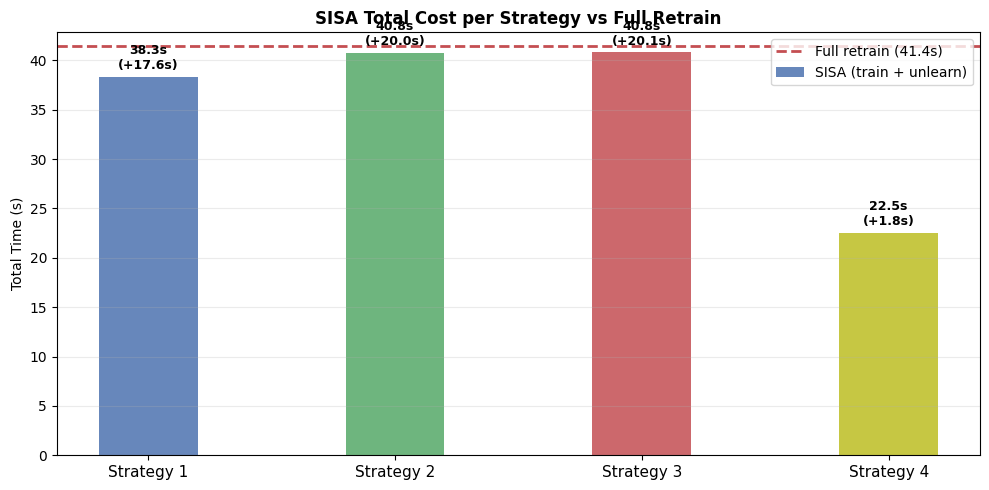

All figures saved to results/


In [86]:
# Figure 8: Speed
t_unlearn_times = [t_unlearn_s1, t_unlearn_s2, t_unlearn_s3, t_unlearn_s4]
t_sisa_totals = [t_sisa_full + t for t in t_unlearn_times]
t_full_total = 2 * t_sisa_full  # original train + full retrain from scratch

fig, ax = plt.subplots(figsize=(10, 5))
x, w = np.arange(4), 0.4
for bar, v, t_ul in zip(ax.bar(x, t_sisa_totals, w, color=s_colors, alpha=0.85, label='SISA (train + unlearn)'), t_sisa_totals, t_unlearn_times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{v:.1f}s\n(+{t_ul:.1f}s)', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.axhline(t_full_total, color='#C44E52', linestyle='--', lw=2, label=f'Full retrain ({t_full_total:.1f}s)')
ax.set_xticks(x); ax.set_xticklabels(strategies, fontsize=11)
ax.set_ylabel('Total Time (s)')
ax.set_title('SISA Total Cost per Strategy vs Full Retrain', fontsize=12, fontweight='bold')
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.25)
save_fig('fig_sisa_nn_speed.png')

print("All figures saved to", OUT)